<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/OnStructuralCapacityBSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

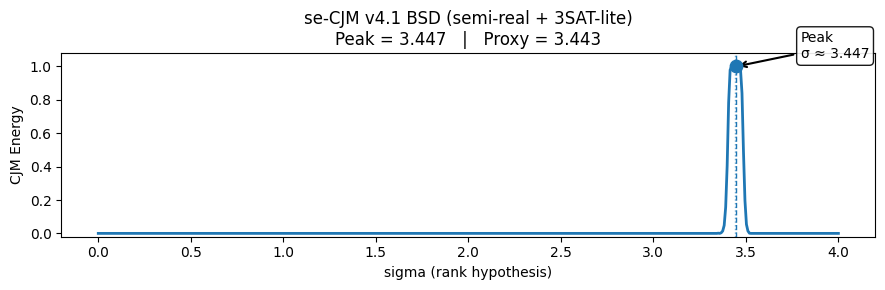

(np.float64(3.44689378757515), np.float64(3.4431141229063735))

In [ ]:
# ============================================================
# Appendix 1: Python Code for BSD Proxy Figure (se-CJM v4.1)
# ============================================================
# se-CJM (software-emulated CJM) implements a 4-step pipeline:
#   (1) BSD-specific arithmetic embedding -> logic-like literals (x1, x2)
#   (2) CJM core engine                  -> sigma-wise admissibility energy
#   (3) Peak localization                -> rank-capacity peak detection
#   (4) Visualization                    -> BSD proxy energy profile
#
# This appendix presents the primary BSD proxy scan used in Figure 1.
# The purpose is to illustrate how semi-real elliptic-curve-like
# invariants may be embedded into a 3SAT-lite structural layer and
# then evaluated through the reusable se-CJM core.
#
# The resulting peak is not interpreted as evidence for the BSD
# Conjecture. It is used only as a proxy-level visualization of how a
# finite BSD-inspired rank-capacity profile may generate a structural
# admissibility landscape.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

TINY = 1e-12


# ==========================================
# Semi-real rank proxy from elliptic-curve-like invariants
# ==========================================
def rank_proxy_from_invariants(N, disc, w, tors):
    """
    Semi-real BSD rank-capacity proxy.

    Returns a proxy in [0,4] derived from elliptic-curve-like invariants.

    Interpretation (proxy):
      - N represents a conductor-like scale
      - disc represents a discriminant-like scale
      - w in {+1,-1} represents a root-number-like parity driver
      - tors represents torsion-like finite structure

    The proxy is not a rank computation.
    It provides a bounded reference coordinate for the BSD capacity scan.
    """
    logN = np.log(max(1.0, float(N)))
    logD = np.log(max(1.0, float(abs(disc))))

    # Scale contribution from conductor-like and discriminant-like terms
    s = 0.55 * np.tanh(logN / 6.0) + 0.35 * np.tanh(logD / 10.0)

    # Parity bias: w=-1 leans toward odd-rank capacity, w=+1 toward even-rank capacity
    parity_bias = 0.35 if (w == -1) else -0.10

    # Small torsion-like correction
    tors_bias = 0.08 * np.tanh((tors - 1) / 4.0)

    # Map to [0,4]
    proxy = 4.0 * np.clip(0.5 + 0.5 * (s + parity_bias + tors_bias), 0.0, 1.0)

    return proxy


# ==========================================
# 3SAT-like structural clause density
# ==========================================
def sat3_density(lits, seed=2026):
    """
    Build lightweight 3SAT-like clauses from Boolean literal streams.

    Given:
      lits : {0,1} array with shape (t, K)

    Local clause:
      C = (li OR lj OR lk)

    Returns:
      sat : per-t clause-satisfaction density in [0,1]

    This is a structural proxy, not a SAT solver.
    """
    rng = np.random.default_rng(seed)
    Tn, K = lits.shape

    if K < 3:
        return np.zeros(Tn)

    # Fixed clause set across t for structural consistency
    m = min(220, (K*(K-1)*(K-2))//6)

    idx = rng.integers(0, K, size=(m, 3))

    # Mild duplicate control while preserving lightweight execution
    idx[:,1] = (idx[:,0] + 1 + idx[:,1]) % K
    idx[:,2] = (idx[:,1] + 1 + idx[:,2]) % K

    a = lits[:, idx[:,0]]
    b = lits[:, idx[:,1]]
    c = lits[:, idx[:,2]]

    sat = (a | b | c).mean(axis=1)

    return sat


# ==========================================
# STEP 1: INPUT MODULE (BSD rank-capacity proxy embedding)
# ==========================================
def step1_input_bsd_encoding_v41(
    param_range,
    t_vals,
    # Semi-real inputs; replace later with real PARI/LMFDB-derived values
    inv_N=11, inv_disc=-20, inv_w=-1, inv_tors=5,
    coupling_alpha=8.5, #12.5 ==> 8.5
    q_factor=2.4,
    seed=2026
):
    """
    BSD proxy embedding (rank-capacity proxy).

    Produces two literals x1, x2 on a (t, sigma) grid.

    Interpretation (proxy):
      - sigma represents candidate rank-capacity coordinate in [0,4]
      - semi-real arithmetic invariants define a bounded proxy coordinate
      - 3SAT-lite clause behavior contributes a structural mismatch penalty
      - phase modulation prevents the profile from becoming purely static

    Output:
      x1, x2       : {0,1} arrays with shape (len(t_vals), len(param_range))
      target_proxy : semi-real BSD capacity coordinate in [0,4]
    """
    rng = np.random.default_rng(seed)
    t_vals = np.asarray(t_vals, dtype=np.float64)
    param_range = np.asarray(param_range, dtype=np.float64)

    Tn, Sn = len(t_vals), len(param_range)
    residual = np.zeros((Tn, Sn), dtype=np.float64)

    # Semi-real BSD capacity reference
    target_proxy = rank_proxy_from_invariants(inv_N, inv_disc, inv_w, inv_tors)

    # Atemporal scan axis
    t_phase = 2 * np.pi * (t_vals / 280.0)

    # Build resonance-probe literal bank
    K = 36
    probe = np.zeros((Tn, K), dtype=np.uint8)

    for k in range(K):
        phase_k = 2 * np.pi * (k / K)
        wave = np.sin(t_phase + phase_k)

        # Thresholded oscillatory probe -> literal stream
        probe[:, k] = (wave > 0.75).astype(np.uint8)

    # 3SAT-lite satisfaction density over probe literals
    sat3 = sat3_density(probe, seed=seed)

    # Higher satisfaction means lower mismatch
    sat_mismatch = (1.0 - sat3)

    # Construct residual field over (t, sigma)
    for j, sigma in enumerate(param_range):
        base_mismatch = np.abs(sigma - target_proxy)

        phase_shift = 2 * np.pi * (j / max(1, Sn - 1))
        oscillation = 1.0 + 0.22 * np.sin(t_phase + phase_shift)
        jitter = 0.01 * rng.normal(size=Tn)

        # BSD residual = rank-capacity mismatch + 3SAT structural penalty
        r_t = base_mismatch * oscillation + 0.18 * sat_mismatch + jitter
        residual[:, j] = np.clip(r_t, 0.0, None)

    # Residual -> admissibility field
    admissibility_field = np.exp(-coupling_alpha * (residual + TINY))

    # x1: strongest BSD admissibility events
    x1 = (admissibility_field >= np.quantile(admissibility_field, 0.9965)).astype(np.uint8)

    # x2: sharpened companion layer
    x2 = (admissibility_field**q_factor >= np.quantile(admissibility_field**q_factor, 0.992)).astype(np.uint8)

    return x1, x2, target_proxy


# ==========================================
# STEP 2: CJM CORE ENGINE (kept reusable)
# ==========================================
def step2_cjm_core_engine_v41(x1, x2, gate="OR", beta=24.0):
    """
    Universal CJM core engine.

    A. 3-literal clause interaction (minimal coupling)
       clauses_i = f(x1_i, x2_i, x1_{i-1})
    B. sigma-wise admissibility density (mean over t)
    C. Contrast mapping -> normalized "energy" in [0,1]
    """
    x1_prev = np.roll(x1, shift=1, axis=0)
    x1_prev[0, :] = 0

    if gate == "OR":
        clauses = (x1 | x2 | x1_prev).astype(np.uint8)
    elif gate == "AND3":
        clauses = (x1 & x2 & x1_prev).astype(np.uint8)
    else:
        clauses = ((x1 + x2 + x1_prev) >= 2).astype(np.uint8)

    sat_density = clauses.mean(axis=0)
    energy = 1 / (1 + np.exp(-beta * (sat_density - np.median(sat_density))))
    energy = (energy - energy.min()) / (energy.max() - energy.min() + TINY)

    return energy


# ==========================================
# STEP 3: Peak localization
# ==========================================
def run_seCJM_v41_bsd(inv_N=11, inv_disc=-20, inv_w=-1, inv_tors=5):
    """
    Runs the se-CJM v4.1 BSD proxy pipeline:
      1) BSD proxy embedding -> x1, x2
      2) CJM energy(sigma)
      3) peak localization
      4) plot BSD rank-capacity energy profile

    Note:
      The semi-real proxy is only a bounded structural reference.
      The peak should be interpreted as a proxy-level discrimination
      signature, not as a BSD rank computation.
    """
    SIGMA_SPACE = np.linspace(0.0, 4.0, 500)
    T_SPACE = np.arange(0, 10000)

    # STEP 1
    x1, x2, target_proxy = step1_input_bsd_encoding_v41(
        SIGMA_SPACE, T_SPACE,
        inv_N=inv_N, inv_disc=inv_disc, inv_w=inv_w, inv_tors=inv_tors
    )

    # STEP 2
    energy = step2_cjm_core_engine_v41(x1, x2)

    # STEP 3
    peak_sigma = SIGMA_SPACE[np.argmax(energy)]

    # STEP 4
    plt.figure(figsize=(9,3))
    plt.plot(SIGMA_SPACE, energy, linewidth=2)

    # Energy peak
    idx_peak = np.argmax(energy)
    x_peak = SIGMA_SPACE[idx_peak]
    y_peak = energy[idx_peak]

    # Peak guide
    plt.axvline(x_peak, linestyle="--", linewidth=1)

    # Peak marker
    plt.scatter([x_peak], [y_peak], s=80, zorder=5)

    # Peak callout
    label = f"Peak\nσ ≈ {x_peak:.3f}"
    plt.annotate(
        label,
        xy=(x_peak, y_peak),
        xytext=(x_peak + 0.35, min(1.05, y_peak + 0.35)),
        arrowprops=dict(arrowstyle="->", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9),
        fontsize=10
    )

    # Semi-real proxy reference
    plt.axvline(target_proxy, linestyle=":", linewidth=1, alpha=0.6)

    plt.xlabel("sigma (rank hypothesis)")
    plt.ylabel("CJM Energy")
    plt.title(
        f"se-CJM v4.1 BSD (semi-real + 3SAT-lite)\n"
        f"Peak = {x_peak:.3f}   |   Proxy = {target_proxy:.3f}"
    )

    plt.ylim(-0.02, 1.08)
    plt.tight_layout()
    plt.show()

    return peak_sigma, target_proxy


# ==========================================
# MASTER CONTROL (se-CJM v4.1-BSD proxy)
# ==========================================
# Replace the semi-real inputs below with real curve-derived
# invariants in future PARI/LMFDB-based experiments.
# ==========================================
run_seCJM_v41_bsd(inv_N=11, inv_disc=-20, inv_w=-1, inv_tors=5)

In [ ]:
PROCEDURE step1_input_bsd_filter(input_instance):

    # Interpret the input according to its current arithmetic form
    IF input_instance is EllipticCurve E:
        P_N <- SelectPrimeWindow(E)
        S_N <- ExtractLocalPointSignal(E, P_N)
        Theta <- BuildBSDIndicatorEncoding(E, S_N)
        F <- TranslateTo3SAT(Theta)
        Sigma_BSD <- LiftToBSDCapacityRepresentation(F, Theta)

    ELSE IF input_instance is BSDCapacityProfile Theta:
        F <- TranslateTo3SAT(Theta)
        Sigma_BSD <- LiftToBSDCapacityRepresentation(F, Theta)

    ELSE IF input_instance is BSD3SATFormula F:
        Sigma_BSD <- LiftToBSDCapacityRepresentation(F)

    ELSE IF input_instance is SATReducedInstance F:
        Sigma_BSD <- LiftToBSDCapacityRepresentation(F)

    ELSE:
        Sigma_BSD <- input_instance

    # Preserve only BSD-capacity-relevant invariants
    Preserve:
        - local point-count response structure
        - analytic vanishing profile near s = 1
        - rank-capacity consistency
        - torsion and correction-term alignment
        - local/global obstruction indicators
        - clause/indicator coupling structure

    RETURN Sigma_BSD

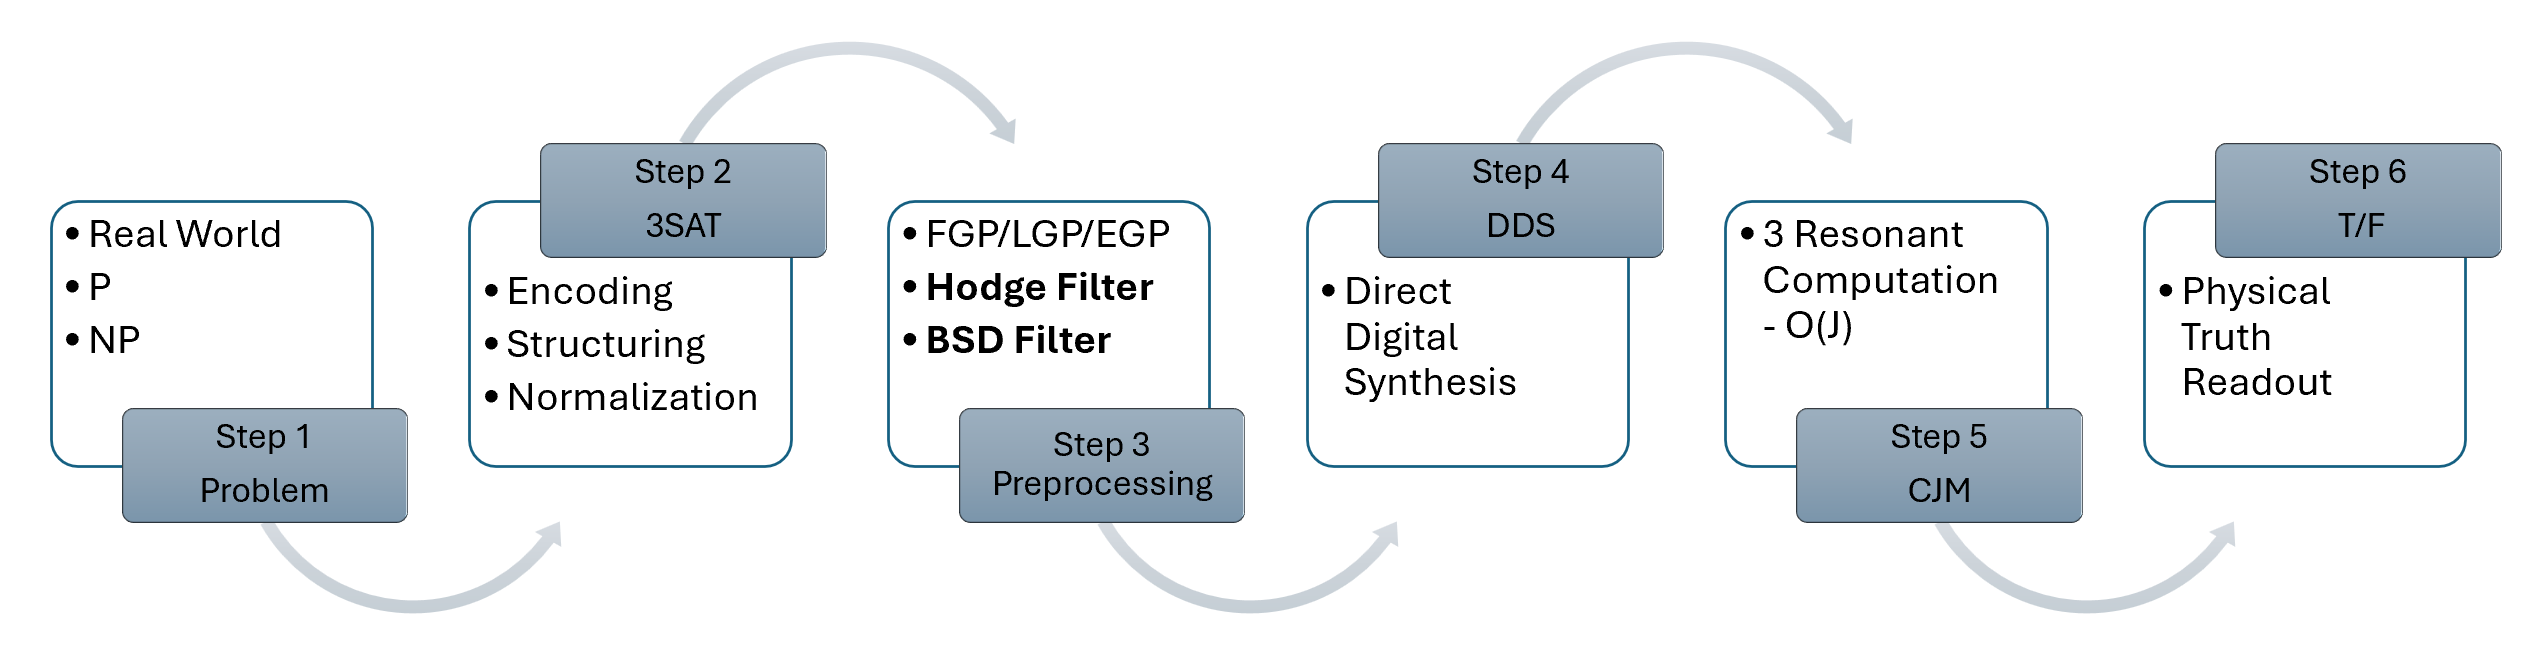

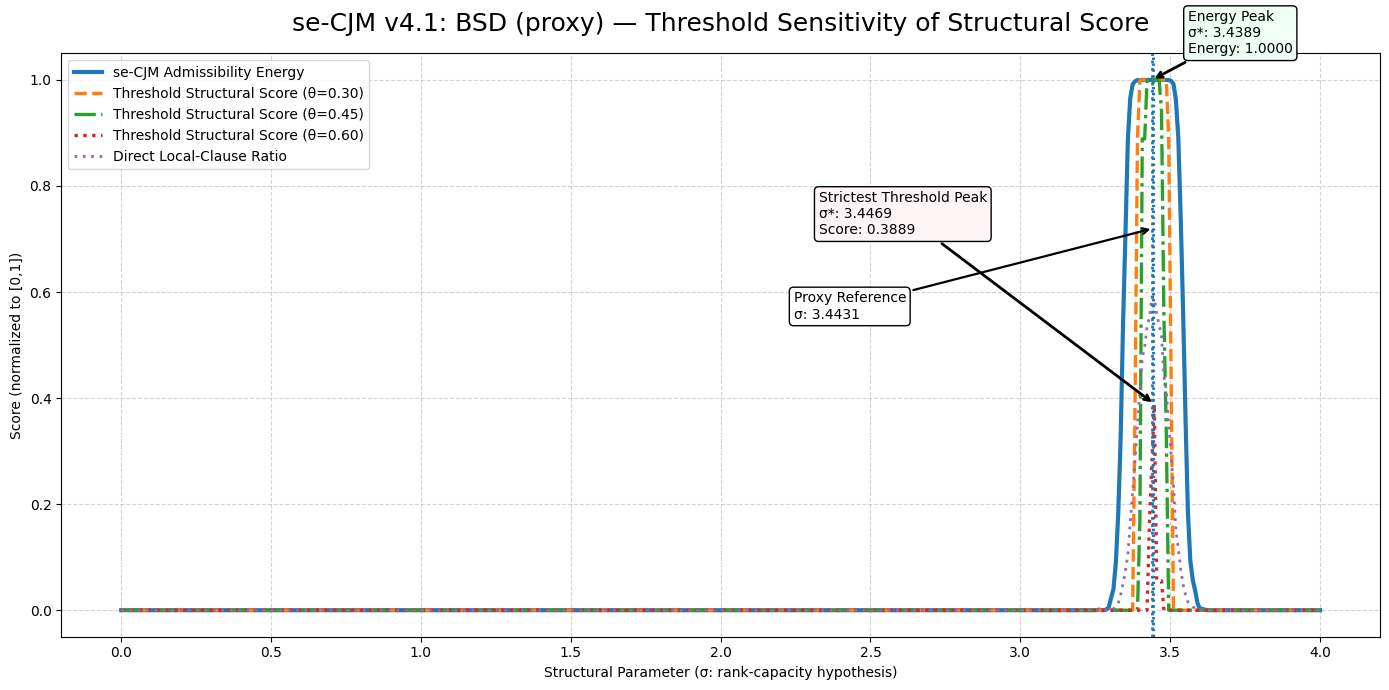

In [ ]:
# ============================================================
# Appendix 3: Python Code for Threshold Sensitivity Figure (se-CJM v4.1 BSD)
# ============================================================
# se-CJM (software-emulated CJM) implements a 4-step pipeline:
#   (1) BSD-specific arithmetic embedding -> logic-like literals (x1, x2)
#   (2) CJM core engine                  -> sigma-wise admissibility energy
#   (3) Threshold structural check       -> local 3SAT-like clause truths
#                                           + threshold pass-rate (PySAT-free)
#   (4) Visualization                    -> theta-sensitivity comparison
#
# This appendix reuses the same BSD proxy pipeline as Figure 1,
# but compares multiple threshold values theta in a unified figure.
# The purpose is to illustrate how stricter thresholds narrow the
# admissible rank-capacity band while preserving the structural core.
#
# Compared with the first BSD proxy figure, this version applies a
# smoother rank-capacity basin and relaxed quantile gates so that the
# sensitivity profile appears as a narrow structural band rather than
# as an overly sharp single-column spike.
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt

TINY = 1e-12


# ==========================================
# Semi-real rank proxy from elliptic-curve-like invariants
# ==========================================
def rank_proxy_from_invariants(N, disc, w, tors):
    """
    Semi-real BSD rank-capacity proxy.

    Returns a proxy in [0,4] derived from elliptic-curve-like invariants.

    Interpretation (proxy):
      - N represents a conductor-like scale
      - disc represents a discriminant-like scale
      - w in {+1,-1} represents a root-number-like parity driver
      - tors represents torsion-like finite structure

    The proxy is not a rank computation.
    It provides a bounded reference coordinate for the BSD capacity scan.
    """
    logN = np.log(max(1.0, float(N)))
    logD = np.log(max(1.0, float(abs(disc))))

    # Scale contribution from conductor-like and discriminant-like terms
    scale_score = 0.55 * np.tanh(logN / 6.0) + 0.35 * np.tanh(logD / 10.0)

    # Parity bias: w=-1 leans toward odd-rank capacity, w=+1 toward even-rank capacity
    parity_bias = 0.35 if (w == -1) else -0.10

    # Small torsion-like correction
    tors_bias = 0.08 * np.tanh((tors - 1) / 4.0)

    # Map to [0,4]
    proxy = 4.0 * np.clip(
        0.5 + 0.5 * (scale_score + parity_bias + tors_bias),
        0.0,
        1.0
    )

    return proxy


# ==========================================
# 3SAT-like structural clause density
# ==========================================
def sat3_density(lits, seed=2026):
    """
    Build lightweight 3SAT-like clauses from Boolean literal streams.

    Given:
      lits : {0,1} array with shape (t, K)

    Local clause:
      C = (li OR lj OR lk)

    Returns:
      sat : per-t clause-satisfaction density in [0,1]

    This is a structural proxy, not a SAT solver.
    """
    rng = np.random.default_rng(seed)
    Tn, K = lits.shape

    if K < 3:
        return np.zeros(Tn)

    # Fixed clause set across t for structural consistency
    m = min(220, (K * (K - 1) * (K - 2)) // 6)

    idx = rng.integers(0, K, size=(m, 3))

    # Mild duplicate control while preserving lightweight execution
    idx[:, 1] = (idx[:, 0] + 1 + idx[:, 1]) % K
    idx[:, 2] = (idx[:, 1] + 1 + idx[:, 2]) % K

    a = lits[:, idx[:, 0]]
    b = lits[:, idx[:, 1]]
    c = lits[:, idx[:, 2]]

    sat = (a | b | c).mean(axis=1)

    return sat


# ==========================================
# STEP 1: INPUT MODULE (BSD rank-capacity proxy embedding)
# ==========================================
def step1_input_bsd_capacity_proxy(
    sigma_range,
    t_vals,
    inv_N=11,
    inv_disc=-20,
    inv_w=-1,
    inv_tors=5,
    coupling_alpha=6.2,
    q=2.2,
    osc_amp=0.18,
    osc_period=280,
    sat_weight=0.14,
    noise=0.015,
    basin_width=0.16,
    q_x1=0.9935,
    q_x2=0.9860,
    seed=2026,
):
    """
    BSD proxy embedding (rank-capacity proxy).

    Produces two literals x1, x2 on a (t, sigma) grid.

    Interpretation (proxy):
      - sigma represents candidate rank-capacity coordinate in [0,4]
      - semi-real arithmetic invariants define a bounded proxy coordinate
      - 3SAT-lite clause behavior contributes a structural mismatch penalty
      - a smoothed rank-capacity basin avoids an overly sharp single-point peak
      - a narrow rank-capacity region may exhibit concentrated admissibility

    Output:
      x1, x2       : {0,1} arrays with shape (len(t_vals), len(sigma_range))
      target_proxy : semi-real BSD capacity coordinate in [0,4]
    """
    rng = np.random.default_rng(seed)

    sigma_range = np.asarray(sigma_range, dtype=np.float64)
    t_vals = np.asarray(t_vals, dtype=np.float64)

    Tn, Sn = len(t_vals), len(sigma_range)
    residual = np.zeros((Tn, Sn), dtype=np.float64)

    # Semi-real BSD capacity reference
    target_proxy = rank_proxy_from_invariants(
        inv_N,
        inv_disc,
        inv_w,
        inv_tors
    )

    # Atemporal scan axis
    t_phase = 2 * np.pi * (t_vals / osc_period)

    # Build resonance-probe literal bank
    K = 36
    probe = np.zeros((Tn, K), dtype=np.uint8)

    for k in range(K):
        phase_k = 2 * np.pi * (k / K)
        wave = np.sin(t_phase + phase_k)

        # Thresholded oscillatory probe -> literal stream
        probe[:, k] = (wave > 0.75).astype(np.uint8)

    # 3SAT-lite satisfaction density over probe literals
    sat3 = sat3_density(probe, seed=seed)

    # Higher satisfaction means lower mismatch
    sat_mismatch = 1.0 - sat3

    # Construct residual field over (t, sigma)
    for j, sigma in enumerate(sigma_range):
        # Smooth rank-capacity basin:
        # avoids an overly sharp cusp at sigma = target_proxy
        base_mismatch = np.sqrt((sigma - target_proxy) ** 2 + basin_width ** 2) - basin_width

        phase_shift = 2 * np.pi * (j / max(1, Sn - 1))
        oscillation = 1.0 + osc_amp * np.sin(t_phase + phase_shift)

        jitter = noise * rng.normal(size=Tn)

        # BSD residual = rank-capacity mismatch + 3SAT structural penalty
        r_t = base_mismatch * oscillation + sat_weight * sat_mismatch + jitter

        residual[:, j] = np.clip(r_t, 0.0, None)

    # Residual -> admissibility field
    admissibility_field = np.exp(-coupling_alpha * (residual + TINY))

    # x1: strongest BSD admissibility events
    # slightly relaxed quantile to avoid a needle-like single-column spike
    thr1 = np.quantile(admissibility_field, q_x1)
    x1 = (admissibility_field >= thr1).astype(np.uint8)

    # x2: sharpened companion layer
    g2 = admissibility_field ** q
    thr2 = np.quantile(g2, q_x2)
    x2 = (g2 >= thr2).astype(np.uint8)

    return x1, x2, target_proxy


# ==========================================
# STEP 2: CJM CORE ENGINE (kept reusable)
# ==========================================
def step2_cjm_core_engine(x1, x2, gate="OR", beta=24.0, mode="logistic"):
    """
    Universal CJM core engine.

    A. 3-literal clause interaction (minimal coupling)
       clauses_i = f(x1_i, x2_i, x1_{i-1})
    B. sigma-wise admissibility density (mean over t)
    C. Contrast mapping -> normalized "energy" in [0,1]
    """
    x1_prev = np.roll(x1, shift=1, axis=0)
    x1_prev[0, :] = 0

    if gate == "MAJ":
        clauses = ((x1 + x2 + x1_prev) >= 2).astype(np.uint8)
    elif gate == "AND3":
        clauses = (x1 & x2 & x1_prev).astype(np.uint8)
    else:
        clauses = (x1 | x2 | x1_prev).astype(np.uint8)

    sat_density = clauses.mean(axis=0)

    if mode == "zscore":
        z = (sat_density - sat_density.mean()) / (sat_density.std() + TINY)
        energy = 1 / (1 + np.exp(-z))
    else:
        center = np.median(sat_density)
        energy = 1 / (1 + np.exp(-beta * (sat_density - center)))

    energy = (energy - energy.min()) / (energy.max() - energy.min() + TINY)

    return energy


# ==========================================
# 3SAT-like local clause builder
# ==========================================
def build_local_clause_truths_for_sigma_window(
    x1_col,
    x2_col,
    gate="OR",
    start=0,
    win=360,
):
    """
    Build local truth values for one sigma-window.

    Local clause:
      f_i = OR(x1_i, x2_i, x1_{i-1})   or   MAJ / AND3

    Returns:
      truths : list[int] with values in {0,1}
    """
    end = min(len(x1_col), start + win)
    N = end - start

    if N <= 2:
        return []

    truths = []

    for i in range(N):
        a = int(x1_col[start + i])
        b = int(x2_col[start + i])

        if i == 0:
            p = int(x1_col[start - 1]) if start - 1 >= 0 else 0
        else:
            p = int(x1_col[start + i - 1])

        if gate == "MAJ":
            val = 1 if (a + b + p) >= 2 else 0
        elif gate == "AND3":
            val = 1 if (a & b & p) == 1 else 0
        else:
            val = 1 if (a | b | p) == 1 else 0

        truths.append(val)

    return truths


# ==========================================
# STEP 3: Threshold structural pass-rate
# ==========================================
def structural_score_per_sigma_threshold(
    x1,
    x2,
    gate="OR",
    win=360,
    stride=120,
    max_windows=18,
    theta=0.30,
):
    """
    For each sigma column, evaluate multiple overlapping windows and compute:

      structural_score(sigma)
        = (# windows with local_truth_ratio >= theta) / (# windows tested)

    This is a PySAT-free replacement for quick execution.

    Also returns:
      direct_rate(sigma) = average local clause truth ratio across windows

    Interpretation:
      - structural_score: threshold pass-rate
      - direct_rate: mean clause truth density
      - overlapping windows produce a smoother threshold-sensitivity profile
    """
    Tn, Sn = x1.shape
    starts = list(range(0, Tn, stride))[:max_windows]

    structural_score = np.zeros(Sn, dtype=np.float64)
    direct_rate = np.zeros(Sn, dtype=np.float64)

    for j in range(Sn):
        x1_col = x1[:, j]
        x2_col = x2[:, j]

        pass_count = 0
        tested = 0
        direct_scores = []

        for start in starts:
            truths = build_local_clause_truths_for_sigma_window(
                x1_col,
                x2_col,
                gate=gate,
                start=start,
                win=win
            )

            if len(truths) == 0:
                local_truth_ratio = 1.0
            else:
                local_truth_ratio = float(np.mean(truths))

            direct_scores.append(local_truth_ratio)
            tested += 1

            if local_truth_ratio >= theta:
                pass_count += 1

        structural_score[j] = pass_count / max(1, tested)
        direct_rate[j] = float(np.mean(direct_scores)) if direct_scores else 1.0

    return np.clip(structural_score, 0.0, 1.0), np.clip(direct_rate, 0.0, 1.0)


# ==========================================
# STEP 4: Plot (theta sensitivity comparison)
# ==========================================
def plot_theta_sensitivity_comparison(
    x_axis,
    energy,
    theta_scores,
    direct_score,
    theta_list,
    target_proxy,
    title,
    save_path="bsd_threshold_tuned.png",
):
    plt.figure(figsize=(14, 7), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    # Base energy curve
    plt.plot(x_axis, energy, linewidth=3, label="se-CJM Admissibility Energy")

    # Threshold curves
    styles = ["--", "-.", ":"]
    for k, theta in enumerate(theta_list):
        curve = theta_scores[k]

        plt.plot(
            x_axis,
            curve,
            linewidth=2.4,
            linestyle=styles[k % len(styles)],
            label=f"Threshold Structural Score (θ={theta:.2f})"
        )

    # Direct local-clause ratio
    plt.plot(
        x_axis,
        direct_score,
        linewidth=2.0,
        linestyle=(0, (1, 2)),
        label="Direct Local-Clause Ratio"
    )

    # Energy peak
    iE = int(np.argmax(energy))
    xE, yE = float(x_axis[iE]), float(energy[iE])

    plt.axvline(xE, linestyle=":", linewidth=2)

    plt.annotate(
        f"Energy Peak\nσ*: {xE:.4f}\nEnergy: {yE:.4f}",
        xy=(xE, yE),
        xytext=(xE + 0.03 * (x_axis[-1] - x_axis[0]), min(1.05, yE + 0.32)),
        arrowprops=dict(arrowstyle="->", lw=2),
        bbox=dict(boxstyle="round", fc="#F0FFF4", ec="black"),
        fontsize=10,
    )

    # Semi-real proxy reference
    plt.axvline(target_proxy, linestyle=":", linewidth=1.6)

    plt.annotate(
        f"Proxy Reference\nσ: {target_proxy:.4f}",
        xy=(target_proxy, 0.72),
        xytext=(target_proxy - 0.30 * (x_axis[-1] - x_axis[0]), 0.55),
        arrowprops=dict(arrowstyle="->", lw=1.6),
        bbox=dict(boxstyle="round", fc="white", ec="black"),
        fontsize=10,
    )

    # Peak callout for strictest threshold
    strict_idx = len(theta_list) - 1
    strict_curve = theta_scores[strict_idx]
    iS = int(np.argmax(strict_curve))
    xS, yS = float(x_axis[iS]), float(strict_curve[iS])

    plt.axvline(xS, linestyle=":", linewidth=1.6)

    plt.annotate(
        f"Strictest Threshold Peak\nσ*: {xS:.4f}\nScore: {yS:.4f}",
        xy=(xS, yS),
        xytext=(xS - 0.28 * (x_axis[-1] - x_axis[0]), min(0.85, yS + 0.32)),
        arrowprops=dict(arrowstyle="->", lw=2),
        bbox=dict(boxstyle="round", fc="#FFF5F5", ec="black"),
        fontsize=10,
    )

    plt.title(title, fontsize=18, pad=16)
    plt.xlabel("Structural Parameter (σ: rank-capacity hypothesis)")
    plt.ylabel("Score (normalized to [0,1])")
    plt.grid(linestyle="--", alpha=0.55)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# ==========================================
# MASTER CONTROL (se-CJM v4.1-BSD-theta tuned)
# ==========================================
def run_seCJM_v41_bsd_theta_sensitivity():
    """
    Runs the se-CJM v4.1 BSD threshold-sensitivity pipeline:
      1) BSD proxy embedding -> x1, x2
      2) CJM energy(sigma)
      3) threshold structural check for multiple theta values
      4) plot theta-sensitivity comparison in one figure

    Recommended comparison:
      - theta = 0.30
      - theta = 0.45
      - theta = 0.60

    Note:
      The thresholds are selected for the tuned BSD proxy profile.
      The purpose is not to decide BSD, but to visualize whether the
      rank-capacity core remains stable as the admissibility criterion
      becomes more selective.
    """
    SIGMA_SPACE = np.linspace(0.0, 4.0, 500)
    T_SPACE = np.arange(0, 10000)

    THETA_LIST = [0.30, 0.45, 0.60]

    # STEP 1
    x1, x2, target_proxy = step1_input_bsd_capacity_proxy(
        SIGMA_SPACE,
        T_SPACE,
        inv_N=11,
        inv_disc=-20,
        inv_w=-1,
        inv_tors=5,
        coupling_alpha=6.2,
        q=2.2,
        osc_amp=0.18,
        sat_weight=0.14,
        noise=0.015,
        basin_width=0.16,
        q_x1=0.9935,
        q_x2=0.9860,
        seed=2026
    )

    # STEP 2
    energy = step2_cjm_core_engine(
        x1,
        x2,
        gate="OR",
        beta=24.0,
        mode="logistic"
    )

    # STEP 3
    theta_scores = []
    direct_score = None

    for theta in THETA_LIST:
        sat_score, direct_tmp = structural_score_per_sigma_threshold(
            x1,
            x2,
            gate="OR",
            win=360,
            stride=120,
            max_windows=18,
            theta=theta
        )

        theta_scores.append(sat_score)

        # Direct local-clause ratio is theta-independent;
        # keep the first one only
        if direct_score is None:
            direct_score = direct_tmp

    # STEP 4
    plot_theta_sensitivity_comparison(
        SIGMA_SPACE,
        energy,
        theta_scores,
        direct_score,
        THETA_LIST,
        target_proxy,
        "se-CJM v4.1: BSD (proxy) — Threshold Sensitivity of Structural Score",
        save_path="bsd_threshold_tuned.png"
    )


# Execution
run_seCJM_v41_bsd_theta_sensitivity()